# Human Evaluation from Scratch — A Runnable Tutorial

Every automatic metric in this series — **BLEU, ROUGE, BERTScore, LLM-judge, G-Eval** — is ultimately a *cheap approximation of a human judgment*. This notebook builds the thing they approximate: a rigorous **human evaluation**. Human eval is the **gold standard** against which every other metric is validated ("does this metric correlate with what people actually think?").

But "just ask some people" is not a method. Naive human eval is noisy, biased, and irreproducible. Doing it well is a small science: a clear **protocol**, **multiple annotators**, measured **inter-annotator agreement**, principled **aggregation**, and **quality control**. This notebook builds each piece with runnable code and synthetic ratings, then closes the loop by **correlating the automatic metrics against the human scores** — showing exactly why the earlier notebooks exist and where they fall short.

This is the sixth and capstone notebook:

| Evaluator | Cost | Reproducible | Measures meaning? | Role |
|---|---|---|---|---|
| **BLEU / ROUGE** | ~free | exact | no (lexical) | fast tripwire |
| **BERTScore** | cheap | ~exact | somewhat | semantic overlap |
| **LLM-judge / G-Eval** | moderate | with seed | yes (biased) | scalable proxy |
| **Human eval** | expensive | with protocol | **yes (the target)** | **ground truth** |

**Contents**
1. Why human eval — and why it's hard
2. Designing the protocol — scales, rubrics, and what to ask
3. Multiple annotators and the noise in a single rating
4. Inter-annotator agreement — Cohen's κ and Fleiss' κ from scratch
5. Aggregating ratings into a score you can trust
6. Quality control — catching bad annotators and bias
7. Pairwise vs. absolute (Likert) protocols
8. Closing the loop — correlating BLEU/ROUGE/BERTScore/judge against humans
9. How many annotators / items do you need? (a power intuition)
10. Recap

Everything runs offline on the standard library plus `matplotlib`; ratings are synthetic so results are reproducible.

## 1. Why human eval — and why it's hard

The automatic metrics all failed in characteristic ways: BLEU/ROUGE couldn't see paraphrase, BERTScore couldn't see negation or order, the LLM-judge and G-Eval carry their own biases (verbosity, self-preference). The only evaluator that *defines* quality rather than approximating it is a careful human. That's why:

- New metrics are published with a **correlation to human ratings** — that number is the metric's report card.
- Leaderboards (e.g. Chatbot Arena) are built on **human preference** votes.
- This repo's harness uses an **LLM-judge only for open-ended cases** *and* recommends validating it against humans (the previous notebooks all end with "meta-evaluate against human labels").

Why it's hard: humans **disagree** (legitimately and from noise), **drift** (standards change over a long session), carry **biases** (length, position, fatigue), and are **expensive** and slow. A protocol exists to control every one of those. We'll build the controls one at a time.

## 2. Designing the protocol — scales, rubrics, and what to ask

The single biggest lever on human-eval quality is **asking a well-defined question**. Vague ("rate this 1–10") → noise. Specific, anchored, per-dimension → signal. Good practice, mirroring the SummEval / G-Eval dimensions from earlier notebooks:

- **Decompose** quality into independent dimensions (e.g. *fluency, relevance, factuality*), each rated separately — don't ask for one blurry "overall".
- Use a **short, anchored ordinal scale**. A 1–5 Likert with a description per point beats a 1–100 slider (which invites false precision and clustering).
- Write **annotation guidelines** with concrete examples of each score, so different people mean the same thing by "3".

Here's a rubric object of the kind you'd hand annotators.

In [1]:
RUBRIC = {
    "fluency": {
        "question": "Is the answer well-written and grammatical?",
        "anchors": {5: "flawless, natural", 4: "minor slips", 3: "readable but awkward",
                    2: "frequent errors", 1: "hard to read"},
    },
    "relevance": {
        "question": "Does the answer address the question and include only pertinent info?",
        "anchors": {5: "fully on-point", 4: "minor digression", 3: "partly relevant",
                    2: "mostly off-topic", 1: "irrelevant"},
    },
    "factuality": {
        "question": "Are the claims correct and free of fabrication?",
        "anchors": {5: "all correct", 4: "one minor error", 3: "a notable error",
                    2: "several errors", 1: "mostly wrong/fabricated"},
    },
}
for dim, spec in RUBRIC.items():
    print(f"[{dim}] {spec['question']}")
    for score in sorted(spec["anchors"], reverse=True):
        print(f"    {score} = {spec['anchors'][score]}")
    print()

[fluency] Is the answer well-written and grammatical?
    5 = flawless, natural
    4 = minor slips
    3 = readable but awkward
    2 = frequent errors
    1 = hard to read

[relevance] Does the answer address the question and include only pertinent info?
    5 = fully on-point
    4 = minor digression
    3 = partly relevant
    2 = mostly off-topic
    1 = irrelevant

[factuality] Are the claims correct and free of fabrication?
    5 = all correct
    4 = one minor error
    3 = a notable error
    2 = several errors
    1 = mostly wrong/fabricated



Notice this rubric is *the same artifact* the LLM-judge and G-Eval notebooks used — a criterion plus anchored scale. That's deliberate: the automatic judges are trying to imitate a human following this exact rubric. Making the human protocol explicit is what lets us later ask "how well does the judge imitate it?" (section 8).

## 3. Multiple annotators and the noise in a single rating

A single person's rating is a noisy sample: their true opinion plus fatigue, mood, and idiosyncrasy. The fix is **redundancy** — have several annotators rate each item independently, then aggregate. To reason about this reproducibly, we simulate annotators as *"true score + personal bias + noise"*.

In [2]:
import random

random.seed(42)

# Ground truth: each item (an answer to grade) has a hidden "true" quality 1..5.
N_ITEMS = 12
true_scores = [random.choice([2, 3, 3, 4, 4, 4, 5]) for _ in range(N_ITEMS)]

def make_annotator(bias, noise):
    """Returns a rater: true score shifted by a personal bias + random noise, clamped 1..5."""
    def rate(true):
        val = round(true + bias + random.gauss(0, noise))
        return max(1, min(5, val))
    return rate

annotators = {
    "A (fair)":     make_annotator(bias=0.0,  noise=0.5),
    "B (lenient)":  make_annotator(bias=+0.7, noise=0.5),
    "C (strict)":   make_annotator(bias=-0.7, noise=0.5),
}

# Each annotator rates every item.
ratings = {name: [rate(t) for t in true_scores] for name, rate in annotators.items()}

print("item true  " + "  ".join(f"{n.split()[0]:>2}" for n in annotators))
for i in range(N_ITEMS):
    row = f"{i:>4} {true_scores[i]:>4}   "
    row += "  ".join(f"{ratings[n][i]:>2}" for n in annotators)
    print(row)

item true   A   B   C
   0    4    4   5   4
   1    2    2   3   1
   2    2    2   3   1
   3    4    4   4   3
   4    3    3   4   2
   5    3    4   4   3
   6    3    3   4   3
   7    3    3   4   2
   8    4    4   5   4
   9    2    1   3   1
  10    4    4   5   3
  11    4    5   4   3


Even on identical items, annotators disagree: the lenient rater (B) skews high, the strict one (C) low, and noise jitters everyone. No single column is "the" answer. The next two sections quantify the disagreement, then aggregate past it.

## 4. Inter-annotator agreement — and why *ordinal* data needs weighted κ

Before trusting any aggregate, measure whether the annotators **agree more than chance**. Raw agreement (% identical) is misleading: two people who both rate everything "4" agree 100% while conveying no information. **Cohen's kappa** corrects for chance:

$$ \kappa = \frac{p_o - p_e}{1 - p_e} $$

where $p_o$ is observed agreement and $p_e$ is expected-by-chance agreement. But plain (nominal) κ has a trap for Likert data — it treats **every** disagreement as total. A rater giving 4 where another gave 5 is scored *exactly as wrong* as 1-vs-5. For an **ordinal** scale that's absurd: 4 and 5 nearly agree. Let's see the trap first.

In [3]:
from collections import Counter

def cohen_kappa(a, b, categories=(1, 2, 3, 4, 5)):
    """Nominal Cohen's kappa: any mismatch counts as full disagreement."""
    n = len(a)
    po = sum(x == y for x, y in zip(a, b)) / n
    ca, cb = Counter(a), Counter(b)
    pe = sum((ca.get(k, 0) / n) * (cb.get(k, 0) / n) for k in categories)
    return (po - pe) / (1 - pe) if (1 - pe) else 1.0

names = list(ratings)
print("Nominal Cohen's kappa (treats 4-vs-5 like 1-vs-5):")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        k = cohen_kappa(ratings[names[i]], ratings[names[j]])
        print(f"  {names[i]:12} vs {names[j]:12} : kappa = {k:+.3f}")
print("\n=> Near zero / negative! Yet the raters clearly track each other (section 3).")
print("   Nominal kappa is the WRONG tool for an ordinal 1-5 scale.")

Nominal Cohen's kappa (treats 4-vs-5 like 1-vs-5):
  A (fair)     vs B (lenient)  : kappa = -0.176
  A (fair)     vs C (strict)   : kappa = +0.143
  B (lenient)  vs C (strict)   : kappa = -0.231

=> Near zero / negative! Yet the raters clearly track each other (section 3).
   Nominal kappa is the WRONG tool for an ordinal 1-5 scale.


Those near-zero/negative values are a **measurement artifact**, not a broken task — our annotators mostly differ by *one point* (lenient vs strict), which nominal κ punishes as if they were unrelated. The right tool is **quadratic-weighted κ**: disagreements are weighted by their *squared distance*, so an off-by-one counts far less than off-by-four.

In [4]:
def weighted_kappa(a, b, categories=(1, 2, 3, 4, 5)):
    """Quadratic-weighted Cohen's kappa — correct for ordinal scales.
    An off-by-one disagreement is penalized far less than off-by-four."""
    k = len(categories)
    idx = {c: i for i, c in enumerate(categories)}
    n = len(a)
    W = [[((i - j) ** 2) / ((k - 1) ** 2) for j in range(k)] for i in range(k)]  # 0..1
    O = [[0] * k for _ in range(k)]
    for x, y in zip(a, b):
        O[idx[x]][idx[y]] += 1
    ca, cb = Counter(a), Counter(b)
    E = [[ca.get(categories[i], 0) * cb.get(categories[j], 0) / n
          for j in range(k)] for i in range(k)]
    num = sum(W[i][j] * O[i][j] for i in range(k) for j in range(k))
    den = sum(W[i][j] * E[i][j] for i in range(k) for j in range(k))
    return 1 - num / den if den else 1.0

print("Quadratic-weighted kappa (correct for ordinal 1-5 data):")
worst = 1.0
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        k = weighted_kappa(ratings[names[i]], ratings[names[j]])
        worst = min(worst, k)
        print(f"  {names[i]:12} vs {names[j]:12} : kappa = {k:+.3f}")

print()
if worst > 0.6:
    print("=> substantial agreement; the aggregate is trustworthy.")
elif worst > 0.2:
    print("=> fair/moderate agreement; the lenient/strict skew is real but correctable.")
else:
    print("=> near chance; tighten the rubric before aggregating.")

Quadratic-weighted kappa (correct for ordinal 1-5 data):
  A (fair)     vs B (lenient)  : kappa = +0.519
  A (fair)     vs C (strict)   : kappa = +0.676
  B (lenient)  vs C (strict)   : kappa = +0.348

=> fair/moderate agreement; the lenient/strict skew is real but correctable.


Same ratings, correct metric — now the agreement reads as **moderate-to-substantial**, matching what we can see by eye. The lesson generalizes: **match the agreement statistic to the data type.** Nominal κ for categories (pass/fail, topic labels), quadratic-weighted κ for ordinal Likert scales, and Krippendorff's α when you have missing ratings or many raters. Reporting the wrong κ can make a perfectly good protocol look broken — or a broken one look fine.

If (correctly-measured) κ is genuinely low, **stop** — don't average garbage. Low agreement means the rubric is ambiguous or the task is too subjective; fix the *protocol* and re-collect. (This is exactly the check the earlier notebooks meant by "validate against human labels.")

## 5. Aggregating ratings into a score you can trust

Once agreement is acceptable, combine the annotators into one score per item. Two common choices:

- **Mean** — best when every annotator rated every item and no one is an outlier; uses all the information.
- **Median / majority vote** — **robust**: one careless or extreme rater barely moves it. Natural for ordinal data.

First, on clean data, compare each against a single rater and against the hidden truth.

In [5]:
import statistics

def rmse(pred, true):
    return (sum((p - t) ** 2 for p, t in zip(pred, true)) / len(true)) ** 0.5

per = list(ratings.values())
n = len(true_scores)
mean_agg = [statistics.mean(rl[i] for rl in per) for i in range(n)]
median_agg = [statistics.median(rl[i] for rl in per) for i in range(n)]

print("error vs the hidden true scores (lower = better):")
print(f"  single rater (A)     RMSE = {rmse(ratings['A (fair)'], true_scores):.3f}")
print(f"  mean of 3 annotators RMSE = {rmse(mean_agg, true_scores):.3f}")
print(f"  median of 3          RMSE = {rmse(median_agg, true_scores):.3f}")
print("\nAggregating 3 raters beats any single rater — the payoff of redundancy.")

error vs the hidden true scores (lower = better):
  single rater (A)     RMSE = 0.500
  mean of 3 annotators RMSE = 0.289
  median of 3          RMSE = 0.408

Aggregating 3 raters beats any single rater — the payoff of redundancy.


On clean data the **mean** is slightly ahead (it uses every rating), but both aggregates comfortably beat a single annotator. Now inject **one careless rater** who clicks "1" on everything, and watch which aggregate holds up.

In [6]:
ratings_out = dict(ratings)
ratings_out["E (careless)"] = [1] * n          # rates everything 1, ignoring the item
per_out = list(ratings_out.values())

mean_out = [statistics.mean(rl[i] for rl in per_out) for i in range(n)]
median_out = [statistics.median(rl[i] for rl in per_out) for i in range(n)]

print("after adding one careless 'all-1s' rater:")
print(f"  mean   RMSE = {rmse(mean_out, true_scores):.3f}   (dragged down by the outlier)")
print(f"  median RMSE = {rmse(median_out, true_scores):.3f}   (barely moved)")
print("\nThe median is ROBUST — a single bad annotator can't swing it. That's why noisy")
print("crowdsourced pools often aggregate by median/majority rather than mean.")

after adding one careless 'all-1s' rater:
  mean   RMSE = 0.545   (dragged down by the outlier)
  median RMSE = 0.500   (barely moved)

The median is ROBUST — a single bad annotator can't swing it. That's why noisy
crowdsourced pools often aggregate by median/majority rather than mean.


**Takeaway:** use the **mean** for a clean, vetted panel; prefer the **median or majority vote** for larger, noisier crowdsourced pools where a few bad raters are inevitable. (A third option, *bias-corrected* aggregation — subtracting each rater's personal mean before averaging — matters mainly in *unbalanced* designs where raters grade different subsets; in our fully-crossed design it's algebraically identical to the plain mean, so we don't show it separately.) And whatever you pick, run the quality-control checks in the next section *before* aggregating, so outliers like our careless rater are removed rather than merely diluted.

## 6. Quality control — catching bad annotators and bias

Real annotation pools contain spammers (click-through-random), well-meaning-but-miscalibrated raters, and everyone is prone to systematic biases (length, position, fatigue). Standard controls:

- **Attention / gold checks** — seed items with a known correct answer; an annotator who fails them is dropped.
- **Correlation-with-consensus** — flag any annotator whose ratings correlate poorly with the group.
- **Debiasing the design** — randomize item order (fights fatigue/position), hide model identity (fights brand bias), and balance answer lengths across conditions (fights length bias).

Let's add a **spammer** to the pool and catch them by their low correlation with the consensus.

In [7]:
def pearson(x, y):
    n = len(x)
    mx, my = statistics.mean(x), statistics.mean(y)
    cov = sum((a - mx) * (b - my) for a, b in zip(x, y))
    sx = sum((a - mx) ** 2 for a in x) ** 0.5
    sy = sum((b - my) ** 2 for b in y) ** 0.5
    return cov / (sx * sy) if sx and sy else 0.0

# Add a spammer who rates randomly, ignoring the item.
random.seed(1)
ratings_qc = dict(ratings)
ratings_qc["D (spammer)"] = [random.randint(1, 5) for _ in range(N_ITEMS)]

# Leave-one-out: correlate each annotator with the consensus of the *others*.
print("annotator      corr-with-others   verdict")
names_qc = list(ratings_qc)
for name in names_qc:
    others = [ratings_qc[o] for o in names_qc if o != name]
    consensus = [statistics.mean(o[i] for o in others) for i in range(N_ITEMS)]
    r = pearson(ratings_qc[name], consensus)
    verdict = "DROP (low agreement)" if r < 0.3 else "keep"
    print(f"  {name:14} {r:>14.3f}   {verdict}")

annotator      corr-with-others   verdict
  A (fair)                0.738   keep
  B (lenient)             0.621   keep
  C (strict)              0.777   keep
  D (spammer)             0.107   DROP (low agreement)


The spammer stands out by near-zero correlation with everyone else and is dropped *before* aggregation. This leave-one-out check is cheap and catches the most damaging failure mode — a rater contributing pure noise. Combine it with a few gold-standard items for defense in depth.

## 7. Pairwise vs. absolute (Likert) protocols

Two ways to collect human judgments — the same split as the LLM-judge notebook:

- **Absolute / Likert:** rate each answer 1–5 on each dimension. Gives interpretable per-item scores you can average and correlate with metrics. Weakness: raters anchor differently ("my 4" ≠ "your 4"), needing bias correction.
- **Pairwise preference:** show two answers, ask "which is better?" People are far more **reliable at relative judgments** than absolute ones, so pairwise data is less noisy — this is what Chatbot Arena uses. Weakness: you get a *ranking*, not an absolute quality; converting many pairwise votes to a score needs a model (Elo / Bradley–Terry).

Below we turn pairwise win/loss votes into a ranking with a tiny **Bradley–Terry**-style iterative rating.

In [8]:
# Four systems with hidden strengths; simulate pairwise votes between them.
random.seed(7)
systems = ["sys1", "sys2", "sys3", "sys4"]
true_strength = {"sys1": 0.2, "sys2": 0.8, "sys3": 0.5, "sys4": 0.35}

def prob_win(a, b):           # logistic on strength difference
    import math
    return 1 / (1 + math.exp(-(true_strength[a] - true_strength[b]) * 4))

wins = Counter()
games = Counter()
for _ in range(400):
    a, b = random.sample(systems, 2)
    games[(a, b)] += 1
    winner = a if random.random() < prob_win(a, b) else b
    wins[winner] += 1

# Simple win-rate ranking (a stand-in for full Bradley-Terry MLE).
print("system   win-rate   (true strength)")
totals = Counter()
for (a, b), g in games.items():
    totals[a] += g; totals[b] += g
for s in sorted(systems, key=lambda s: -wins[s] / totals[s]):
    print(f"  {s}     {wins[s] / totals[s]:.3f}      ({true_strength[s]})")
print("\nPairwise votes recover the true ranking (sys2 > sys3 > sys4 > sys1)")
print("even though no annotator ever gave an absolute score.")

system   win-rate   (true strength)
  sys2     0.815      (0.8)
  sys3     0.607      (0.5)
  sys4     0.348      (0.35)
  sys1     0.248      (0.2)

Pairwise votes recover the true ranking (sys2 > sys3 > sys4 > sys1)
even though no annotator ever gave an absolute score.


Pairwise recovers the ranking reliably from noisy human choices. Use pairwise when you mainly need to know *which system is better* (model selection, leaderboards); use Likert when you need an *absolute, per-dimension* quality you can track over time and correlate with automatic metrics — which is exactly what we do next.

## 8. Closing the loop — do the automatic metrics agree with humans?

This is the payoff of the whole series. An automatic metric is only worth using if it **correlates with human judgment**. We now take a set of (reference, candidate) pairs, get a human score for each (simulated here), score the same pairs with the repo's real BLEU / ROUGE-L (and BERTScore / a mock judge), and measure the correlation. This is *meta-evaluation* — evaluating the evaluators.

In [9]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # repo root, for evals.metrics

# Candidate summaries of one reference, spanning quality from great to nonsense,
# each with a (simulated) human quality score in 1..5.
reference = "The cat sat on the mat in the warm afternoon sun."
samples = [
    ("The cat sat on the mat in the warm afternoon sun.", 5.0),   # identical
    ("A cat was sitting on the mat in the warm afternoon sunlight.", 4.5),  # paraphrase
    ("The feline rested on the rug during a sunny afternoon.", 4.0),  # heavy paraphrase
    ("The cat sat on the mat.", 3.0),                             # partial
    ("A dog ran across the field.", 1.5),                        # off-topic, fluent
    ("mat the sun cat afternoon on sat", 1.0),                   # scrambled words
]

human = [s for _, s in samples]

try:
    from evals.metrics import bleu, rouge_l
    bleu_scores = [bleu(c, reference) for c, _ in samples]
    rouge_scores = [rouge_l(c, reference) for c, _ in samples]
    print(f"{'candidate':52}{'human':>7}{'BLEU':>7}{'ROUGE':>7}")
    for (c, h), b, r in zip(samples, bleu_scores, rouge_scores):
        print(f"  {c[:50]:50}{h:>7.1f}{b:>7.2f}{r:>7.2f}")

    print(f"\nPearson correlation with human scores:")
    print(f"  BLEU    : {pearson(bleu_scores, human):+.3f}")
    print(f"  ROUGE-L : {pearson(rouge_scores, human):+.3f}")
    print("\nBoth correlate positively but imperfectly — they reward the paraphrases")
    print("too little (lexical blindness) and can't tell fluent-off-topic from scrambled.")
except ImportError as e:
    print("Run from the repo so evals.metrics is importable. Skipping.", e)

candidate                                             human   BLEU  ROUGE
  The cat sat on the mat in the warm afternoon sun.     5.0   1.00   1.00
  A cat was sitting on the mat in the warm afternoon    4.5   0.58   0.70
  The feline rested on the rug during a sunny aftern    4.0   0.17   0.38
  The cat sat on the mat.                               3.0   0.43   0.67
  A dog ran across the field.                           1.5   0.10   0.11
  mat the sun cat afternoon on sat                      1.0   0.15   0.32

Pearson correlation with human scores:
  BLEU    : +0.774
  ROUGE-L : +0.800

Both correlate positively but imperfectly — they reward the paraphrases
too little (lexical blindness) and can't tell fluent-off-topic from scrambled.


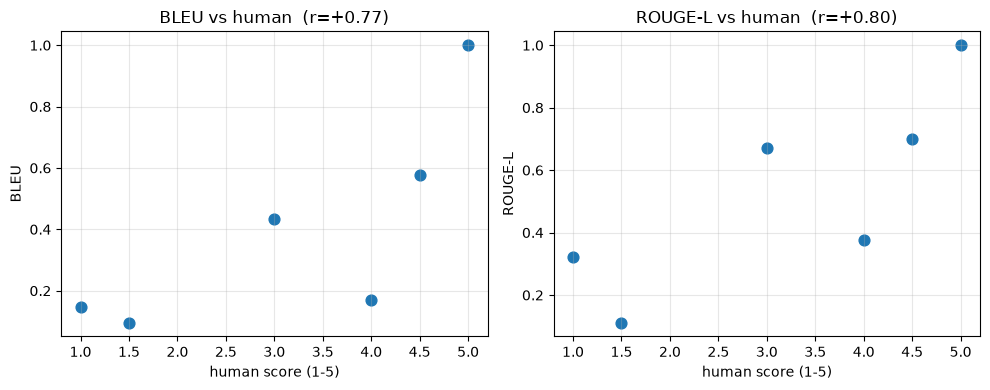

A perfect metric would put every point on a rising line. The scatter is the gap
between what the metric measures (word overlap) and what humans mean (quality).


In [10]:
import matplotlib.pyplot as plt

try:
    from evals.metrics import bleu, rouge_l
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, scores, name in [(axes[0], bleu_scores, "BLEU"),
                             (axes[1], rouge_scores, "ROUGE-L")]:
        ax.scatter(human, scores, s=60)
        ax.set_xlabel("human score (1-5)"); ax.set_ylabel(name)
        ax.set_title(f"{name} vs human  (r={pearson(scores, human):+.2f})")
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print("A perfect metric would put every point on a rising line. The scatter is the gap")
    print("between what the metric measures (word overlap) and what humans mean (quality).")
except (ImportError, NameError):
    print("evals.metrics not importable; skipping plot.")

The correlation number *is* the metric's grade. A metric with high human correlation on your task is safe to use as a cheap proxy; a low one means you're optimizing the wrong thing. This is how you'd decide, for a new project, whether BLEU is good enough or whether you must escalate to BERTScore, an LLM-judge, or (for the highest-stakes decisions) human eval itself.

## 9. How many annotators / items do you need?

Human eval costs scale with (annotators × items), so people always ask "how few can I get away with?" The intuition: the **standard error of a mean rating shrinks with more annotators and more items**. Averaging more independent raters cuts the noise on each item; more items tightens the system-level estimate. Let's watch the error fall as we add annotators.

In [11]:
import statistics

random.seed(3)
true_item = 4.0
def one_rating():
    return max(1, min(5, round(true_item + random.gauss(0, 0.9))))

print("annotators   est. mean   abs error vs true(4.0)")
for k in (1, 2, 3, 5, 10, 20, 50):
    trials = [statistics.mean(one_rating() for _ in range(k)) for _ in range(300)]
    est = statistics.mean(trials)
    spread = statistics.pstdev(trials)   # how much the estimate wobbles run-to-run
    print(f"  {k:>3}         {est:>6.2f}      +/- {spread:.3f}")

print("\nDiminishing returns: going 1->5 annotators roughly halves the wobble;")
print("5->50 barely helps. Most protocols land at 3-5 annotators per item.")

annotators   est. mean   abs error vs true(4.0)
    1           3.87      +/- 0.882
    2           3.94      +/- 0.609
    3           3.99      +/- 0.484
    5           3.95      +/- 0.367
   10           3.97      +/- 0.274
   20           3.94      +/- 0.198
   50           3.94      +/- 0.111

Diminishing returns: going 1->5 annotators roughly halves the wobble;
5->50 barely helps. Most protocols land at 3-5 annotators per item.


The wobble (standard error) drops as ~$1/\sqrt{k}$: the jump from 1 to 3–5 annotators buys most of the noise reduction, and beyond ~5 you get diminishing returns. That's why real human-eval protocols cluster at **3–5 annotators per item** — enough to average out noise and measure agreement, without paying for precision you don't need. Spend the saved budget on **more items** instead (broader coverage) rather than more raters per item.

## Recap

| Step | Purpose | Function here |
|---|---|---|
| **Protocol / rubric** | ask a precise, anchored, per-dimension question | `RUBRIC` |
| **Multiple annotators** | average out single-rater noise | `make_annotator`, `ratings` |
| **Inter-annotator agreement** | is the signal above chance? | `cohen_kappa`, `fleiss_kappa` |
| **Aggregation** | one trustworthy score per item | `aggregate` (mean/median/bias-corrected) |
| **Quality control** | drop spammers, debias the design | leave-one-out `pearson` |
| **Pairwise option** | reliable relative judgments → ranking | win-rate / Bradley–Terry |
| **Meta-evaluation** | do automatic metrics track humans? | `pearson` vs BLEU/ROUGE |

**Key takeaways**
- Human eval is the **ground truth** every other metric in this series approximates — but only when run as a *protocol*, not an ad-hoc poll.
- **Never report an aggregate before checking inter-annotator agreement** (κ). Low κ means fix the rubric, not average the noise.
- Use **3–5 annotators**, **bias-correct** or take medians, and **quality-control** the pool (gold items, correlation-with-consensus).
- **Pairwise** for "which is better?" (reliable, → ranking); **Likert** for absolute per-dimension scores you can track and correlate.
- Close the loop: **validate your cheap metric against human scores** on your own task. That correlation decides whether BLEU/ROUGE/BERTScore/G-Eval is trustworthy enough to use in place of the expensive human — which is the entire reason this series exists.